# Assignment (II)

---


## Please write your full name/names and student IDs here:




*   Full Name: Michael Murphy (Q1, Q2, Q5 - Tasks TODO)
*   Student ID: 222636120



---


# Question 1. (3 points)
* **For this question, please follow the steps outlined below:**
## Part (a):

* **Data Loading:** Read the lymph dataset from your mounted Google Drive using Pandas.

* **Data Splitting:** Split the dataset randomly into a 60% training set and a 40% test set using scikit-learn's train_test_split function.

* **Handling Categorical Data:** Encode categorical attributes with one-hot encoding using pandas.get_dummies, dropping the first attribute to avoid redundancy.

* **Decision Tree Classifier (1st Experiment):** Train a Decision Tree classifier in scikit-learn on the training data, setting the splitting criterion to "entropy," and requiring a minimum of 4 samples to split an internal node. Keep other settings unchanged.

* **Reproducibility:** Set the random_state to 32 in train_test_split and DecisionTreeClassifier to make your codes reproducible.

* **Performance Evaluation (1st Experiment):** Report the Decision Tree classifier's accuracy on the test data. Also, generate a high-resolution tree visualization (use plt.figure(figsize=(12, 8), dpi=300)).





The accuracy of the trained classifier is: 88.33%


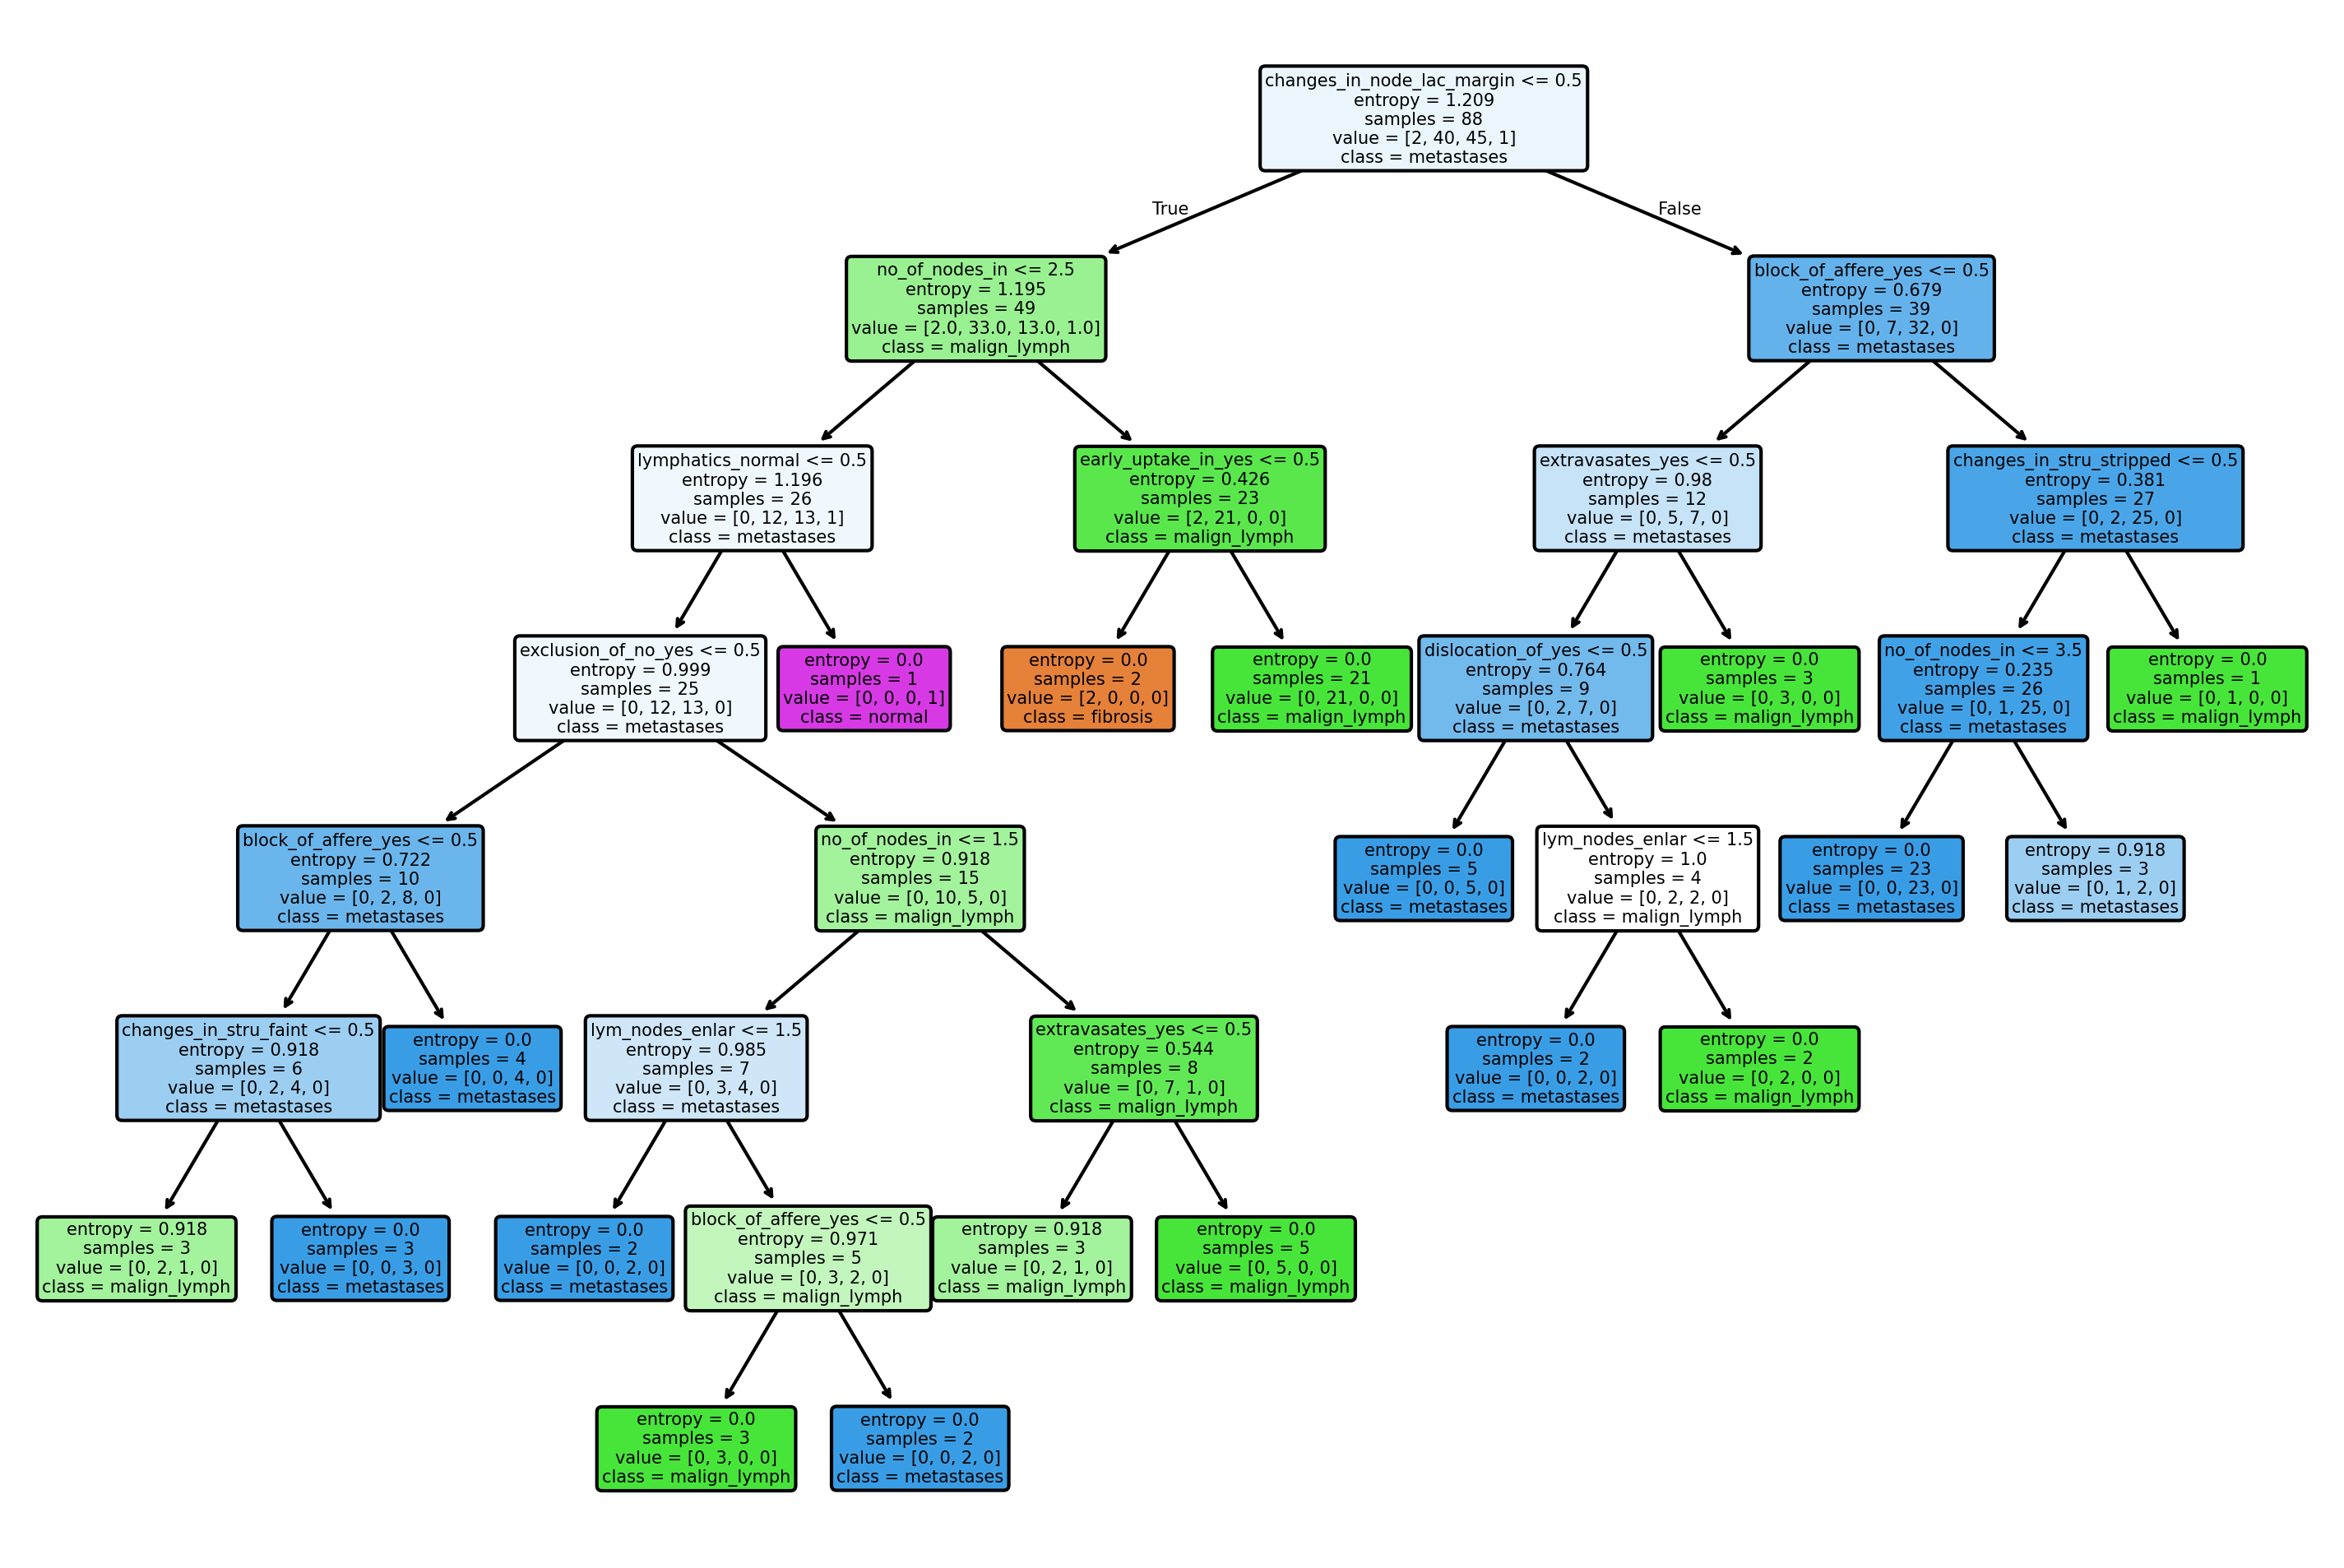

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv("/content/drive/MyDrive/data-mining-assignment3/datasets/lymph.csv")  # Load your dataset
df = pd.read_csv("lymph.csv")  # Load your dataset

#.............................................................................
# write the rest here

# 0. Extra Data Preparation

## Dataset has "'" in the column names
## Need to remove these quotes, as they are causing column name mismatches when calling pd.get_dummies
# print(df.columns.tolist())    # Shows column names, with surrounding quotes "'"
df.columns = [col.strip().replace("'", "") for col in df.columns]
# print(df.columns.tolist())    # Column names have no quotes now



# 1. Handling Categorical Data

## eClass: Scikit-learn primarily operates with numerical data and does not inherently support categorical attributes, 
## except for the target attribute in classification problems. To work with categorical attributes in your feature set, 
## you will typically need to encode them into a numerical format, often using techniques like one-hot encoding.

## Notebook: Encode categorical attributes with one-hot encoding using pandas.get_dummies, dropping the first attribute to avoid redundancy.

# Note: The assignment calls for data splitting, and then handling categorical data, but I have opted to do this in reverse.
# This is because when the data is split into testing and training data first,
# and then each dataset's categorical columns are one-hot encoded with pd.get_dummies,
# the two datasets end up with different amounts of columns; 33 in the training data, 32 in the testing data.
# Specifically, in random_state=32, the testing data is missing the "changes_in_stru_no" column.
# This is likely because the testing data doesn't have any samples where changes_in_stru=no.
# This mismatch causes an issue when trying to make predictions on the trained classifier later.
# However, doing the encoding first and *then* splitting the data ensures that both datasets have the same columns.

# Function for encoding categorical data with one-hot encoding
# Assumes that `dataset` is a pandas frame, and that the columns in `cols` do exist in `dataset`
# Drops the first attribute by default
def categorical_to_onehot(dataset, columns, drop_first=True):
    return pd.get_dummies(dataset, columns=columns, drop_first=drop_first)


# Specify the categorical columns in the dataset
categorical_cols = ['lymphatics', 'block_of_affere', 'bl_of_lymph_c', 'bl_of_lymph_s', 'by_pass', 'extravasates', 'regeneration_of', 'early_uptake_in',
                    'changes_in_lym', 'defect_in_node', 'changes_in_node', 'changes_in_stru', 'special_forms', 'dislocation_of', 'exclusion_of_no']

# Then encode the categorical data in the dataset
df_catencoded = categorical_to_onehot(df, categorical_cols)
# print(df_catencoded)

# First attempt: Encode categorical data in the both data splits
# train_data_catencoded = categorical_to_onehot(train_data, categorical_cols)
# test_data_catencoded = categorical_to_onehot(test_data, categorical_cols)
# print(train_data_catencoded)
# print(test_data_catencoded)



# 2. Data Splitting

# Function for Data Splitting
# Uses 60% vs. 40% split and random_state=32 by default, can use other values if necessary
def split_data(dataset, train_proportion=0.6, random_state=32):
    dataset_size = len(dataset)
    train_size = int(train_proportion * dataset_size)
    test_size = dataset_size - train_size
    return train_test_split(dataset, test_size=test_size, train_size=train_size, random_state=random_state)


# Perform data splitting using the function's default values
# Split the encoded dataset into training and testing data
train_data_catencoded, test_data_catencoded = split_data(df_catencoded)
# print(train_data_catencoded)
# print(test_data_catencoded)

# First attempt: Split the original dataset
# train_data, test_data = split_data(df)
# print(train_data)
# print(test_data)



# 3. Decision Tree Classifier (1st Experiment)

## eClass: Set the criterion of the "DecisionTreeClassifier" algorithm to "entropy" and the minimum number of samples required to split an internal node to 4
## Notebook: Set the random_state to 32 in train_test_split and DecisionTreeClassifier to make your codes reproducible.
## Keep the other settings unchanged

# Function for extracting the column of a dataset containing the target labels for that data
# Assumes that `dataset` contains both features and labels, and that `label_col` exists in `dataset` and represents the column with labels
def separate_labels_and_features(dataset, label_col='class'):
    dataset_labels = dataset[label_col]
    dataset_features = dataset.drop(label_col, axis=1)
    return dataset_features, dataset_labels


# Function for training a decision tree classifier on a given dataset
# Assumes that `training_data` contains both features and labels
# By default, uses 'entropy' criterion, a minimum sample split of 4, and random state of 32
def train_clf(training_data, label_col='class', criterion='entropy', min_samples_split=4, random_state=32):
    # First separate features and labels
    training_data_features, training_data_labels = separate_labels_and_features(training_data, label_col)
    
    # Then initialise and train the classifier using the separated features and labels
    clf = DecisionTreeClassifier(criterion=criterion, min_samples_split=min_samples_split, random_state=random_state)
    clf.fit(training_data_features, training_data_labels)
    return clf


# Train a Decision Tree Classifier on the lymph dataset
clf_lymph = train_clf(train_data_catencoded)



# 4. Performance Evaluation (1st Experiment)

## eClass: Report the accuracy of the Decision Tree classifier on the test dataset. Additionally, plot the constructed tree.

# Function for evaluating a trained decision tree classifier on a given test dataset
# Assumes that `testing_data` contains both features and labels
def evaluate_clf(clf, testing_data, label_col='class'):
    # First separate features and labels
    testing_data_features, testing_data_labels = separate_labels_and_features(testing_data, label_col)

    # Then make predictions using the trained classifier
    testing_data_predictions = clf.predict(testing_data_features)

    # Check the accuracy of these predictions
    accuracy = accuracy_score(testing_data_labels, testing_data_predictions)
    print(f"The accuracy of the trained classifier is: {accuracy*100:.2f}%")

    # Plot a visualisation of the tree
    # Note: using round-edged, filled-in nodes, as they look more pleasant. Also using the max font size possible while avoiding overlapping nodes
    plt.figure(figsize=(12, 8), dpi=300)
    plot_tree(clf, feature_names=testing_data_features.columns, class_names=clf.classes_, filled=True, rounded=True, fontsize=5)
    plt.show()

    return testing_data_predictions, accuracy


# Evaluate the lymph-trained Decision Tree Classifier
clf_lymph_predictions, clf_lymph_accuracy = evaluate_clf(clf_lymph, test_data_catencoded)

#.............................................................................


## Part (b):


Modify the minimum samples required for splitting to 32 and re-run the experiment. Report the accuracy of the Decision Tree classifier with the modified parameter and create a visualization of the tree. Discuss the differences between the two Decision Trees and their respective results, highlighting how changing the minimum samples for splitting affects the tree structure and performance.


The accuracy of the trained classifier is: 76.67%


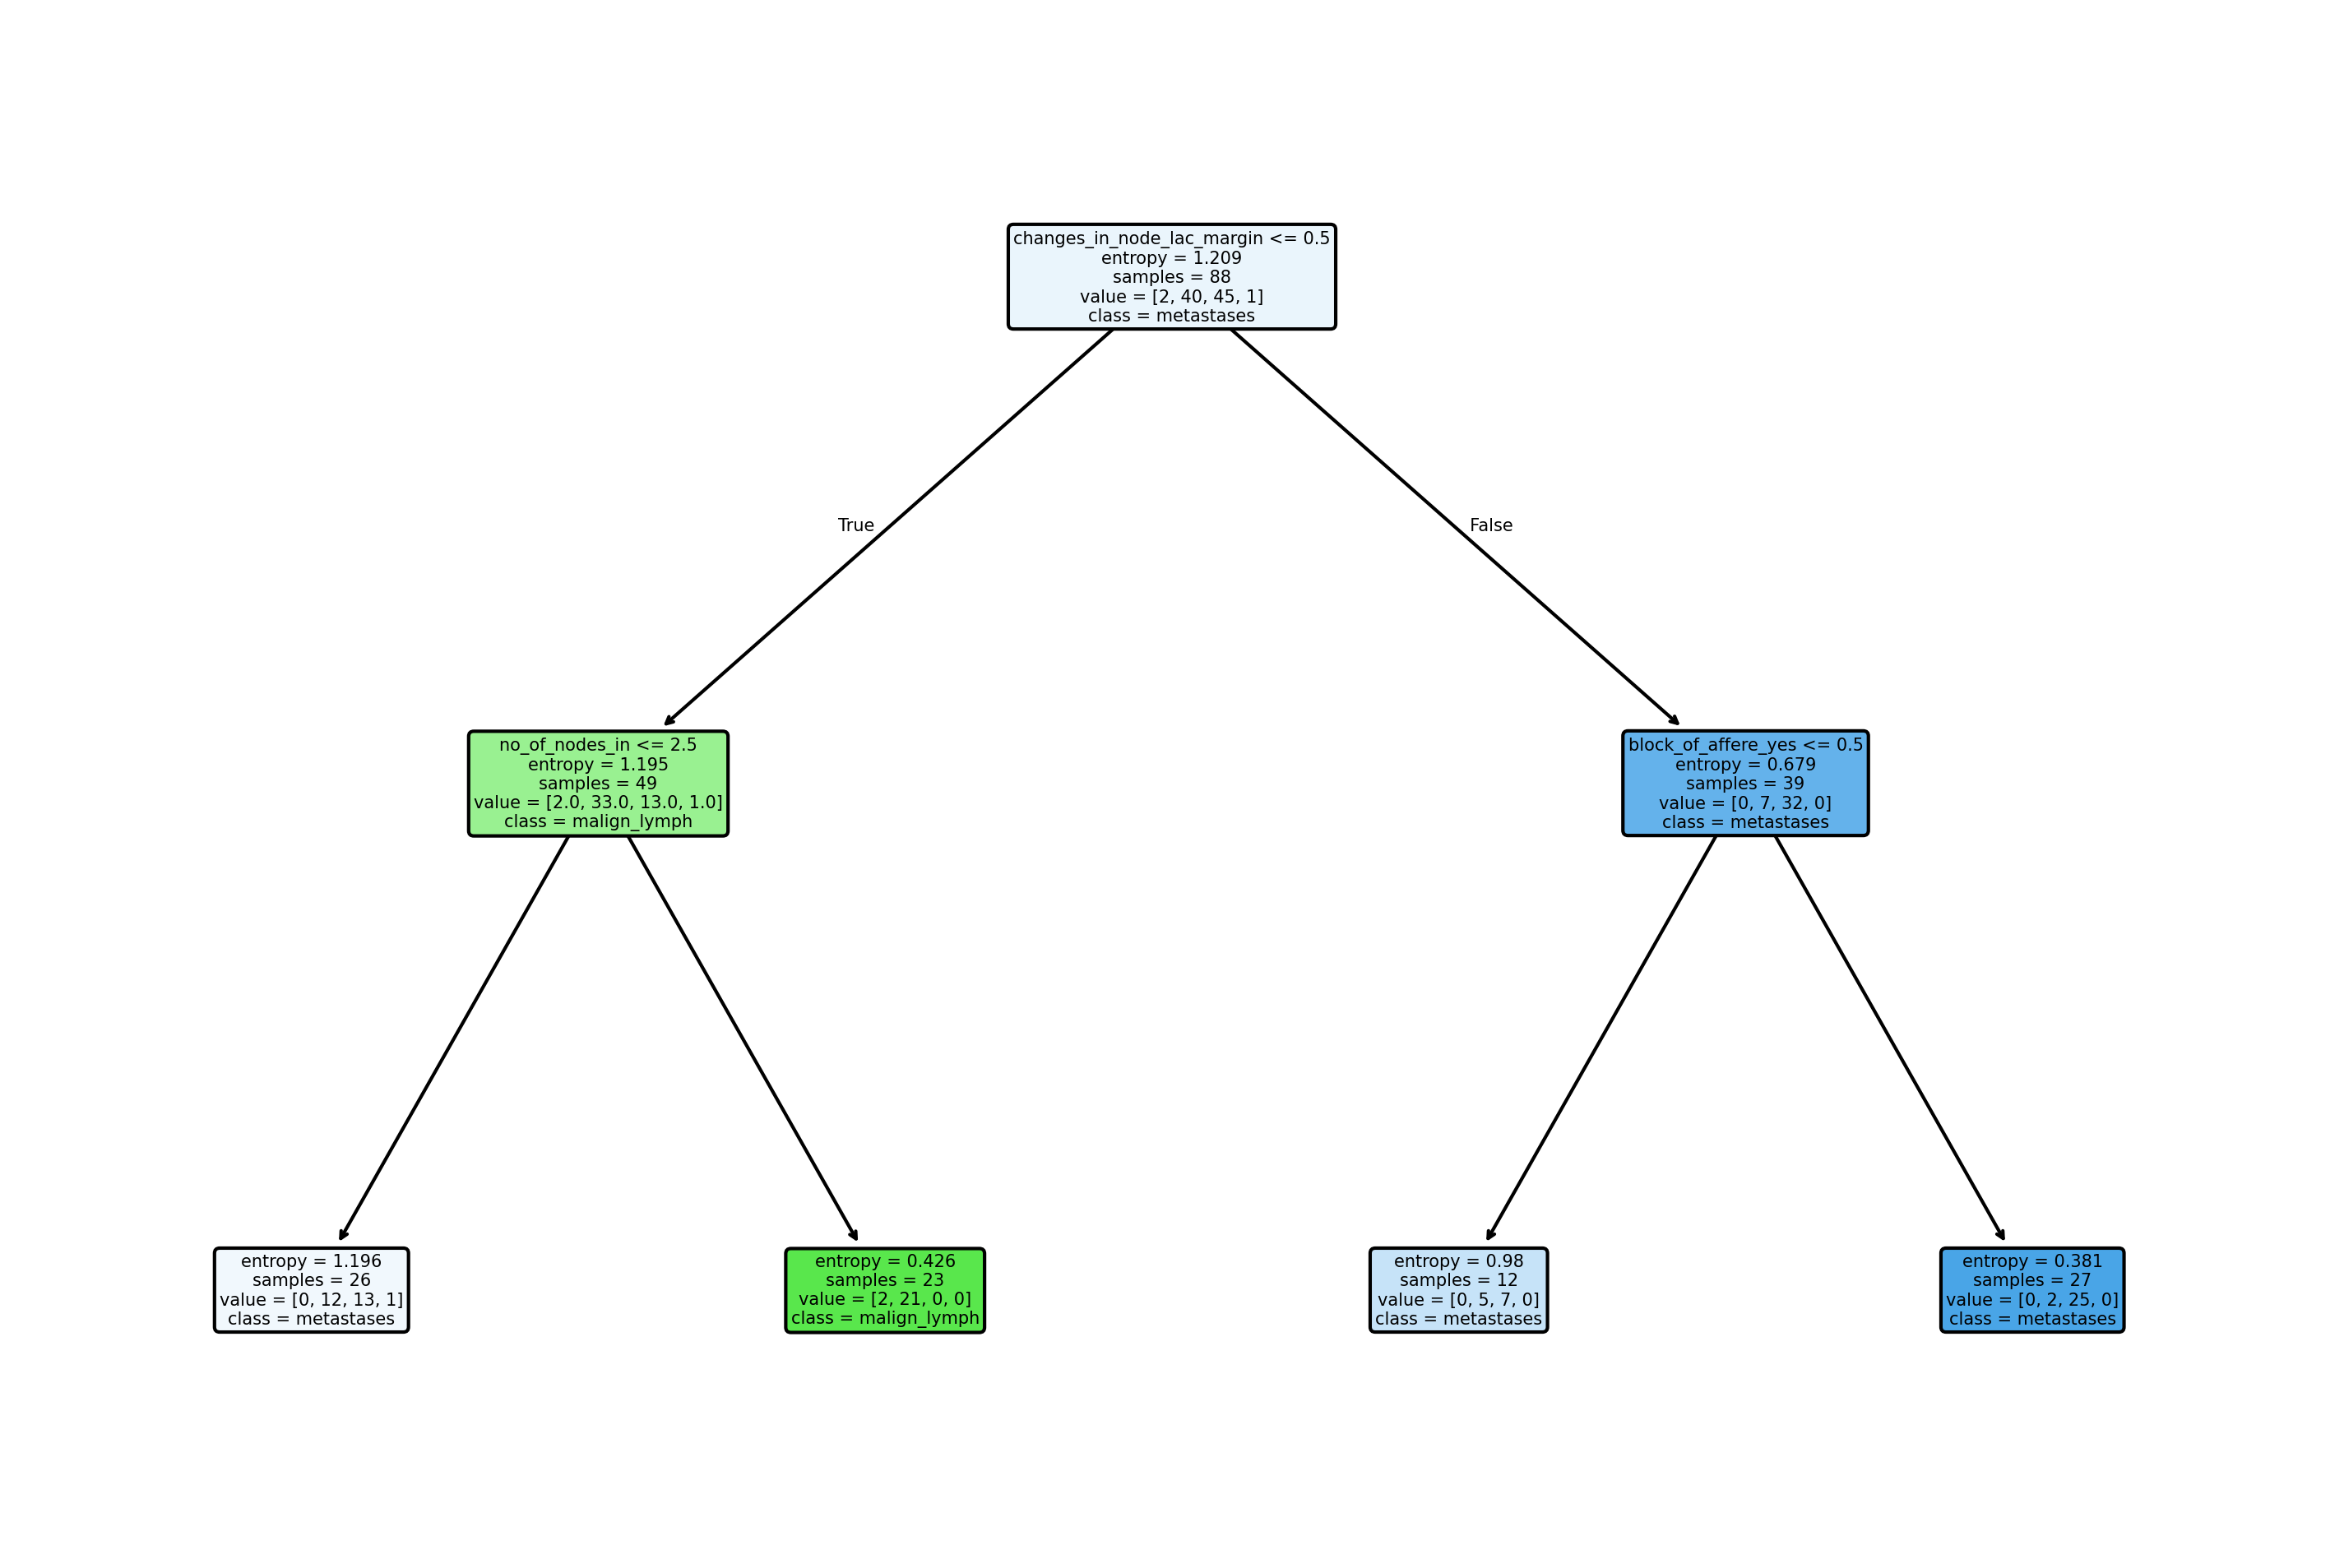

In [4]:

#.............................................................................
# write the rest here

# 1. Decision Tree Classifier (2nd Experiment)

## eClass: Change the minimum samples required for splitting to 32 and re-run the experiment.

# Train a new classifier, using a minimum sample split of 32 instead of 4
clf_lymph2 = train_clf(train_data_catencoded, min_samples_split=32)


# 2. Performance Evaluation (2nd Experiment)
## eClass: Report the accuracy of the Decision Tree classifier with the new parameter and create a visualization of the tree. 
# Evaluate the newly trained classifier
clf_lymph2_predictions, clf_lymph2_accuracy = evaluate_clf(clf_lymph2, test_data_catencoded)

#.............................................................................




---


**Put your discussion here**


Discuss here.

From eClass: Discuss the differences between the two Decision Trees and their respective results, 
highlighting how changing the minimum samples for splitting affects the tree structure and performance.


Firstly, it should be noted that the two classifiers differ only in the minimum number of samples required
to split a node (`min_samples_split`), where the first classifier requires 4 nodes, and the second classifier
requires 32. There are no other differences, not even in randomness, as we have enforced deterministic fitting
by setting `random_state` to 32 in both cases. This setup gives us a very clear picture of the effect of using
a larger value for `min_samples_split`.

The first, and most obvious, difference between the two classifiers is in their actual tree structure. The
first tree is a lot more complex in terms of structure, with 35 nodes, compared with only 7 nodes in the
second tree. Interestingly, the second tree is exactly the same as the first 3 levels of the first tree,
both in terms of the number of samples in the 7 nodes, and also the representative feature values shown in
the plotted trees. However, the first tree continues splitting the data for a further 5 levels, resulting
in leaf nodes with much smaller numbers of samples (mostly less than 4). The increased complexity of the first
tree confers a significant performance benefits; the accuracy of the two classifiers are 88.33% and 76.67%,
respectively.

One immediately obvious reason for the lower performance of the second classifier is that its tree does not
have *any* nodes that represent the "normal" or "fibrosis" classes, meaning that it will **never** classify
these types of samples correctly. Instead, it will misclassify samples in these classes as "metastases" or
"malign_lymph". The reason that the second classifier missed out on these nodes is that our training dataset
only had a small number of samples of these classes. Given that the second classifier only splits nodes when
there are at least 32 samples found, it was unable to split itself enough to represent these classes.

Given these observations, we could naturally conclude that the first classifier is the better choice for
future use. However, we must take care to not simply assume that a higher `min_samples_split` size is always
bad. With a different dataset, using a `min_samples_split` size of 4 might lead to overfitting on the
training data, as the tree's structure will be too tailored to the specific values of the training data
features, and might struggle to generalise to other datasets.

No matter what, we must always ensure that we thoroughly evaluate our classifier, to ensure that it is
properly fine-tuned to its use case. Our simple accuracy score is, of course, a solid and simple measure,
but in practise we will likely need more sophisticated techniques like K-fold cross validation to further
tweak our classifier for better performance.



---


# Question 2. (5 points)
## Part (a):
*  Write a Python function named "preprocess" that preprocesses and prepares
datasets for machine learning. It must take a training dataset and an optional test dataset as input. The code must first identify categorical and numerical attributes, then handle missing values by imputing the mean for numerical attributes and the most frequent value for categorical attributes. It is worth noting that to determine if an attribute is numerical, the process should involve checking its data type and potentially examining the number of unique values. This is necessary because an attribute may appear to have an "object" data type but could, in fact, be numerical in nature.

*  Subsequently, the "preprocess" code must standardize the numerical attributes by removing the mean and scaling to unit variance., and encodes categorical attributes using one-hot encoding.

*  If a test dataset is provided, it must undergo the same preprocessing steps, ensuring that the imputation for missing values and data scaling are performed based on the values obtained from the training dataset, thus maintaining consistency between the two datasets.

*  At the end, the function must return the preprocessed training and test datasets as (X_train, y_train, X_test, y_test) tuple if the test dataset exists. Otherwise it must return (X_train, y_train). X stands for independent processed attributes, while y indicates the class attribute.

In [5]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
def preprocess(train_df, test_df=None, n_unique_threshold=0.1, label_col='class', missing_value_placeholder='?'):
    #.............................................................................
    # write your codes here

    # eClass: Create a Python function called "preprocess" to prepare datasets for machine learning. It takes 
    # a training dataset and an optional test dataset. First, it identifies categorical and numerical attributes,
    # imputing missing values with means for numerical and modes for categorical. Then, it standardizes numerical
    # attributes and encodes categorical ones using one-hot encoding. If a test dataset is provided, 
    # it undergoes the same preprocessing, ensuring consistency by using statistics from the training dataset.

    # We will start by separating the label columns from our other columns, using the function
    # that we defined in Q1
    training_df_features, training_df_labels = separate_labels_and_features(train_df, label_col)
    # print(training_df_features)
    # print(training_df_labels)

    # Now we should identify which columns are categorical, and which are numerical
    # The naive approach would be to simply check the types reported by `training_df_features.dtypes`
    # print(training_df_features.dtypes)

    # With this simple approach, we can simply extract the columns that report numerical types
    numerical_cols = training_df_features.select_dtypes(include=["number"]).columns.tolist()

    # However, this has shortcomings, because if even a single value from a numerical column has a non-numerical
    # value (e.g., a "?" representing missing data), then `dtypes` will report that entire column as "object".
    # This happens with columns "A2" and "A14". We need to write code that is resistant to this generalisation.

    # We can do this by inspecting any columns with non-"number" data types more closely, and seeing how many unique
    # values are contained in those columns - columns with a high number of unique values are probably numeric
    n = len(train_df)
    categorical_cols = []       # Also keep track of the categorical columns
    for col in training_df_features.select_dtypes(exclude=["number"]).columns:
        # If the ratio of unique values to total values is high (say above 10%), then the column is probably numeric
        n_unique = train_df[col].nunique()
        if (n_unique / n) > n_unique_threshold:
            # print(col, n_unique, n_unique / n)
            numerical_cols.append(col)
        # If the number of unique values is low, we will assume that it is categorical
        else:
            categorical_cols.append(col)

    # Now our lists of numerical and categorical columns are complete
    # print(numerical_cols)
    # print(categorical_cols)
    # print(training_df_features[numerical_cols])
    # print(training_df_features[categorical_cols])


    # Impute means for numerical columns, and modes for categorical columns
    training_df_features_imputed = training_df_features.copy()

    # First, need to replace placeholder values in our numerical columns with NaN, so that SimpleImputer can process them
    training_df_features_imputed[numerical_cols] = training_df_features_imputed[numerical_cols].replace(missing_value_placeholder, np.nan)

    # Now we can use SimpleImputer to impute the means for these columns
    num_imputer = SimpleImputer(strategy='mean')
    training_df_features_imputed[numerical_cols] = num_imputer.fit_transform(training_df_features_imputed[numerical_cols])

    # Impute modes for categorical columns
    # This can be done directly without any transformation - just need to specify the value that represents missing data
    cat_imputer = SimpleImputer(strategy='most_frequent', missing_values=missing_value_placeholder)
    training_df_features_imputed[categorical_cols] = cat_imputer.fit_transform(training_df_features_imputed[categorical_cols])


    # Standardise (normalise?) numerical columns, and encode categorical columns with one-hot encoding
    training_df_features_imputed_standardised_encoded = training_df_features_imputed.copy()

    # We can use StandardScaler.fit_transform to learn the means and variances of the numerical columns in training data,
    # and to then standardise those columns with this info, in a single function call
    scaler = StandardScaler()
    training_df_features_imputed_standardised_encoded[numerical_cols] = scaler.fit_transform(
        training_df_features_imputed_standardised_encoded[numerical_cols]
        )

    # For encoding categorical columns, we simply use our `categorical_to_onehot` function from Q1
    training_df_features_imputed_standardised_encoded = categorical_to_onehot(training_df_features_imputed_standardised_encoded, categorical_cols)

    # Now we are ready to return the training data; just need to assign the proper variable names
    X_train = training_df_features_imputed_standardised_encoded
    y_train = training_df_labels

    # If testing data was provided, we also need to preprocess this:
    if test_df is not None:
        # Separate the feature and label columns
        test_df_features, test_df_labels = separate_labels_and_features(test_df, label_col)

        # No need to reidentify which columns are numerical/categorical - can move straight to imputing, standardising, and encoding
        # In this case, we can use the already-trained imputers and scaler, so that the test data is transformed in a way that
        # is consistent with the training data - i.e., we will use the `transform` methods instead of the `fit_transform` methods
        test_df_features_imputed_standardised_encoded = test_df_features.copy()
        test_df_features_imputed_standardised_encoded[numerical_cols] = test_df_features_imputed_standardised_encoded[numerical_cols].replace(missing_value_placeholder, np.nan)
        test_df_features_imputed_standardised_encoded[numerical_cols] = num_imputer.transform(test_df_features_imputed_standardised_encoded[numerical_cols])
        test_df_features_imputed_standardised_encoded[categorical_cols] = cat_imputer.fit_transform(test_df_features_imputed_standardised_encoded[categorical_cols])
        test_df_features_imputed_standardised_encoded[numerical_cols] = scaler.fit_transform(test_df_features_imputed_standardised_encoded[numerical_cols])
        test_df_features_imputed_standardised_encoded = categorical_to_onehot(test_df_features_imputed_standardised_encoded, categorical_cols)

        # Assign proper variable names
        X_test = test_df_features_imputed_standardised_encoded
        y_test = test_df_labels
        
    #.............................................................................
    if test_df is not None:
        return X_train, y_train, X_test, y_test
    else:
        # If no test dataset is provided, return only the preprocessed training dataset
        return X_train, y_train


## Part (b)
In this task, your objective is to assess the performance of various machine learning classifiers for a credit classification problem. To ensure result reproducibility, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. For the MLP, configure two hidden layers with 100 and 50 hidden units, respectively, and set max_iter to 1000. For the Random Forest, set the number of trees in the forest to 100. Finally, report the accuracy achieved on the test dataset.

In [6]:
# eClass: You are given a training data set and a test data set on credit card application approval. The data sets describe a total of
# 690 customers (552 for training and 138 for testing) with 16 attributes. The last attribute is the class attribute describing whether
# the customer's application was approved. Several of the condition attributes contain missing values (which are marked by "?"). All
# attribute names and values have been changed to meaningless symbols to protect the confidentiality of the data.

# Please use the "preprocess" function you wrote in the previous part to handle missing values and standardize your numerical features.
# Then adopt the following algorithms to learn a classification model from the preprocessed training data set and test the model on
# the preprocessed test data set:
# - Decision Tree Classifier (DecisionTreeClassifier)
# - k-Nearest Neighbor (KNeighborsClassifier) with k=1 
# - k-Nearest Neighbor (KNeighborsClassifier) with k=3
# - Gaussian Naive Bayes (GaussianNB)
# - Logistic Regression (LogisticRegression)
# - MLP Neural Network (MLPClassifier)
# - Random Forest (RandomForestClassifier)

# Please report the classification accuracy of each algorithm on the test set. To ensure result reproducibility, set the random_state
# to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. For the MLP, configure two hidden layers with 100 and 50
# hidden units, respectively, and set max_iter to 1000. For the Random Forest, set the number of trees in the forest to 100.

In [7]:
# import necessary libraries

# Load the training and test datasets
# credit_train = pd.read_csv("/content/drive/MyDrive/data-mining-assignment3/datasets/credit-a-train.csv")
# credit_test = pd.read_csv("/content/drive/MyDrive/data-mining-assignment3/datasets/credit-a-test.csv")
credit_train = pd.read_csv("credit-a-train.csv")
credit_test = pd.read_csv("credit-a-test.csv")

# Preprocess the datasets and split them into features (X) and target (y)
X_train, y_train, X_test, y_test = preprocess(credit_train, credit_test)

#.............................................................................
# write your codes here
# First, import the classifiers that we will be using
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# The skeleton code already calls "preprocess" function on the provided datasets, giving us X_train, y_train, X_test, and y_test
print("Training and testing data has been pre-processed")

# This pre-processed data can now be given to each of the classifiers mentioned, to see how they perform
# All classifier are left with their default values, except for the following:
# - n_neighbours=1 for first KNN, and 3 for second KNN
# - random_state=42 in DT, KFold (is this supposed to be KNN? KNN doesn't have random state...), MLP, and RF
# - hidden_layer_sizes=(100, 50) in MLP
# - max_iter=1000 in MLP
# - n_estimators=100 in RF (seems to be the default anyway)
n_neighbors1 = 1
n_neighbors2 = 3
random_state = 42
hidden_layer_sizes = (100, 50)
max_iter = 1000
n_estimators = 100

# Create each classifier
clf_credit_dt = DecisionTreeClassifier(random_state=random_state)
clf_credit_knn1 = KNeighborsClassifier(n_neighbors=n_neighbors1)
clf_credit_knn2 = KNeighborsClassifier(n_neighbors=n_neighbors2)
clf_credit_gnb = GaussianNB()
clf_credit_lr = LogisticRegression()
clf_credit_mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, random_state=random_state)
clf_credit_rf = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)

# Train each classifier on the pre-processed training data
clf_credit_dt.fit(X_train, y_train)
clf_credit_knn1.fit(X_train, y_train)
clf_credit_knn2.fit(X_train, y_train)
clf_credit_gnb.fit(X_train, y_train)
clf_credit_lr.fit(X_train, y_train)
clf_credit_mlp.fit(X_train, y_train)
clf_credit_rf.fit(X_train, y_train)
print("Classifiers have been trained")

# Make predictions on the pre-processed testing data with each classifier
y_pred_dt = clf_credit_dt.predict(X_test)
y_pred_knn1 = clf_credit_knn1.predict(X_test)
y_pred_knn2 = clf_credit_knn2.predict(X_test)
y_pred_gnb = clf_credit_gnb.predict(X_test)
y_pred_lr = clf_credit_lr.predict(X_test)
y_pred_mlp = clf_credit_mlp.predict(X_test)
y_pred_rf = clf_credit_rf.predict(X_test)
print("Predictions have been made")

# Calculate and output the accuracy of each classifier
accuracy_dt = accuracy_score(y_test, y_pred_dt)
accuracy_knn1 = accuracy_score(y_test, y_pred_knn1)
accuracy_knn2 = accuracy_score(y_test, y_pred_knn2)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"The accuracy of the trained classifiers are:")
print(f"- Decision Tree: {accuracy_dt*100:.2f}%")
print(f"- k-Nearest Neighbor (with k=1): {accuracy_knn1*100:.2f}%")
print(f"- k-Nearest Neighbor (with k=3): {accuracy_knn2*100:.2f}%")
print(f"- Gaussian Naive Bayes: {accuracy_gnb*100:.2f}%")
print(f"- Logistic Regression: {accuracy_lr*100:.2f}%")
print(f"- MLP Neural Network: {accuracy_mlp*100:.2f}%")
print(f"- Random Forest: {accuracy_rf*100:.2f}%")

# Also calculate average accuracy
accuracies = [accuracy_dt, accuracy_knn1, accuracy_knn2, accuracy_gnb , accuracy_lr, accuracy_mlp, accuracy_rf]
accuracy_avg = np.average(accuracies)
print(f"The average accuracy across all trained classifiers was: {accuracy_avg*100:.2f}%.")
#.............................................................................

Training and testing data has been pre-processed
Classifiers have been trained
Predictions have been made
The accuracy of the trained classifiers are:
- Decision Tree: 72.46%
- k-Nearest Neighbor (with k=1): 73.91%
- k-Nearest Neighbor (with k=3): 80.43%
- Gaussian Naive Bayes: 84.06%
- Logistic Regression: 85.51%
- MLP Neural Network: 86.23%
- Random Forest: 85.51%
The average accuracy across all trained classifiers was: 81.16%.




---


**Put your discussion here**

The accuracy of the trained classifiers are:
- Decision Tree: 72.46%
- k-Nearest Neighbor (with k=1): 73.91%
- k-Nearest Neighbor (with k=3): 80.43%
- Gaussian Naive Bayes: 84.06%
- Logistic Regression: 85.51%
- MLP Neural Network: 86.23%
- Random Forest: 85.51%

The average accuracy across all trained classifiers was 81.16%.

Out of all of these classifiers, the one that made the highest number of correct predictions on the testing
data was the **MLP Neural Network** (86.23%), which contained two hidden layers (lengths 100 and 50,
respectively). The classifier with the lowest number of correct predictions was the **Decision Tree** (72.46%).

Based on these results, we may be tempted to assume that an MLP Neural Network is the best classifier for
this type of task. However, as mentioned in the discussion of Q1, the simple accuracy score is not necessarily
the most thorough method for evaluating a classifier. In Q3, we will evaluate classifiers using the more
involved k-fold cross validation.



---


# Question 3. (4 points)
## Part (a)
 Use the ionosphere dataset and Run a 10-fold cross validation to evaluate classification error rate of each algorithm. Use the preprocessing function you have written in question 2. Similar to the previous question, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. For the MLP, configure two hidden layers with 100 and 50 hidden units, respectively, and set max_iter to 1000. For the Random Forest, set the number of trees in the forest to 100.

In [ ]:
# Import necessary libraries
from sklearn.model_selection import cross_val_score, KFold

# Load the Ionosphere dataset and preprocess it
ionosphere_dataset = pd.read_csv("/content/drive/MyDrive/data-mining-assignment3/datasets/ionosphere.csv")
X, y = preprocess(ionosphere_dataset)
#.............................................................................
# write your codes here

# Evaluate classification error rates for several classifiers using 10-fold CV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Common configuration
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
random_state = 42

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=random_state),
    "kNN (k=1)": KNeighborsClassifier(n_neighbors=1),
    "kNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Gaussian NB": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=random_state),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=random_state),
}

error_rates = {}
for name, model in models.items():
    # Accuracy from cross-validation; error rate is 1 - accuracy
    scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')
    error_rate = 1 - scores.mean()
    error_rates[name] = error_rate
    print(f"{name} classification error: {error_rate * 100:.2f}% (accuracy {scores.mean() * 100:.2f}%)")
#.............................................................................


## Part (b)
 Write a piece of code to perform feature selection using mutual information scores (mutual_info_classif in sklearn) on the processed ionosphere dataset (X) with its corresponding class labels (y). Your code must calculate these scores and then must select the top 5 attributes with the highest scores. Report what are these 5 selected attributes.

In [ ]:
# Import the necessary library for feature selection
from sklearn.feature_selection import mutual_info_classif
#.............................................................................
# write your codes here

# Compute mutual information scores for all features
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)

# Select the top 5 attributes with the highest mutual information scores
selected_attrs = mi_series.sort_values(ascending=False).head(5).index.tolist()
print("Top 5 attributes by mutual information (feature: score):")
for feature, score in mi_series.sort_values(ascending=False).head(5).items():
    print(f"- {feature}: {score:.4f}")
#.............................................................................


## Part (c)
Using only the top five attributes selected by the previous feature selection method, repeat k-fold validation to report the classification errors for each classifier. Then, discuss whether the results for each classifier have improved and explore the potential reasons behind any changes.

In [ ]:
# Create a new dataset (X_low_dim) with only the selected attributes
X_low_dim = X[selected_attrs]

#.............................................................................
# write your codes here

# Reuse the same models and evaluation setup from part (a)
low_dim_error_rates = {}
for name, model in models.items():
    scores = cross_val_score(model, X_low_dim, y, cv=kfold, scoring='accuracy')
    error_rate = 1 - scores.mean()
    low_dim_error_rates[name] = error_rate
    print(f"{name} (top-5 features) classification error: {error_rate * 100:.2f}% (accuracy {scores.mean() * 100:.2f}%)")
#.............................................................................




---


**Put your discussion here**


Discuss here.


Question 4 (Comparison of Algorithms) (4 points)

Conduct 10-fold cross-validation to evaluate the following classification learning algorithms:

Decision Tree Classifier (DecisionTreeClassifier)
k-Nearest Neighbor (KNeighborsClassifier) with k=1 
k-Nearest Neighbor (KNeighborsClassifier) with k=3
Gaussian Naive Bayes (GaussianNB)
Logistic Regression (LogisticRegression)
MLP Neural Network (MLPClassifier)
Random Forest (RandomForestClassifier)
on the following data sets from the UCI repository:
Balance-scale data set
Ecoli data set (There is an ID attribute in this data set, which should be removed before learning)
Glass Identification data set (There is an ID attribute in this data set, which should be removed before learning)
Ionosphere Data Set
Iris plant data 
Wine data set
Yeast data set (There is an ID attribute in this data set, which should be removed before learning)
Note that the data file for each data set is the .data file, which is a csv file. After downloading them, you can change their file extension to csv. Also, the information about each data set is in the .names file, where you can find the names, types and meanings of the attributes and which attribute is the class attribute. You can manually add the attribute names to the top of the csv file before loading the csv file in your program.

Please report the classification error rate on each data set and the average classification error rate of each method over all the data sets. Rank the methods according to their average classification error rate. For the top two methods (with the lowest average error rates), are their average error rates significantly different? Why? Comparing the method with the lowest average error rate and the one with the highest error rate, are their error rates significantly different? Why? Briefly discuss the results.


---


 # Question 4. (4 points)
 Report the classification error rate on each data set and the average classification error rate of each method over all the data sets. Rank the methods according to their average classification error rate. For the top two methods (with the lowest average error rates), are their average error rates significantly different? Why? Comparing the method with the lowest average error rate and the one with the highest error rate, are their error rates significantly different? Why? Briefly discuss the results.

 (or result reproducibility, set the random_state to 42 in KFold, Decision Tree, MLP Neural Network, and Random Forest. Configure the MLP with two hidden layers having 100 and 50 hidden units, and set max_iter to 1000.)


In [ ]:
#.............................................................................
# write your codes here

import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Configuration
random_state = 42
kfold = KFold(n_splits=10, shuffle=True, random_state=random_state)
data_dir = "/content/drive/MyDrive/data-mining-assignment3/datasets"

# Datasets to evaluate (adjust label/drop columns if your headers differ)
dataset_configs = [
    {"name": "balance-scale", "file": "balance-scale.csv", "label_col": "class", "drop_cols": []},
    {"name": "ecoli", "file": "ecoli.csv", "label_col": "class", "drop_cols": ["sequence_name", "Sequence Name", "id", "ID"]},
    {"name": "glass", "file": "glass.csv", "label_col": "Type", "drop_cols": ["Id", "ID"]},
    {"name": "ionosphere", "file": "ionosphere.csv", "label_col": "class", "drop_cols": []},
    {"name": "iris", "file": "iris.csv", "label_col": "class", "drop_cols": []},
    {"name": "wine", "file": "wine.csv", "label_col": "class", "drop_cols": []},
    {"name": "yeast", "file": "yeast.csv", "label_col": "class", "drop_cols": ["id", "ID", "Sequence name", "seq_name"]},
]

# Models to compare
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=random_state),
    "kNN (k=1)": KNeighborsClassifier(n_neighbors=1),
    "kNN (k=3)": KNeighborsClassifier(n_neighbors=3),
    "Gaussian NB": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=random_state),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=random_state),
}


def load_dataset(cfg):
    """Load a dataset, drop ID-like columns, and return df plus its label column."""
    path = f"{data_dir}/{cfg['file']}"
    df = pd.read_csv(path)
    drop_cols = [c for c in cfg.get("drop_cols", []) if c in df.columns]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    label_col = cfg.get("label_col") or df.columns[-1]
    if label_col not in df.columns:
        label_col = df.columns[-1]  # fallback to last column if header differs
    return df, label_col


# Collect classification error rates per dataset per model
errors = {}
for cfg in dataset_configs:
    df, label_col = load_dataset(cfg)
    X, y = preprocess(df, label_col=label_col)

    errors[cfg["name"]] = {}
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=kfold, scoring="accuracy")
        error_rate = 1 - scores.mean()
        errors[cfg["name"]][name] = error_rate
        print(f"{cfg['name']} - {name}: error {error_rate * 100:.2f}% (accuracy {scores.mean() * 100:.2f}%)")

# Summaries
error_df = pd.DataFrame(errors).T[models.keys()]
avg_errors = error_df.mean()
print("\nAverage classification error across datasets:")
print(avg_errors.sort_values())

print("\nMethods ranked by lowest average error:")
for rank, (model_name, avg_err) in enumerate(avg_errors.sort_values().items(), start=1):
    print(f"{rank}. {model_name}: {avg_err * 100:.2f}%")

#.............................................................................




---


**Put your discussion here**


Discuss here.




---


# Question 5. (14 points)

In [ ]:
#Please include your code for this section below. You may need to define various functions,
#such as a preprocessing function, and incorporate them into your code.






























**For question 5, your detailed report should be presented in a separate PDF file.**